## XGBOOST Models

## Check GPU

In [12]:
import subprocess, warnings, platform, os, psutil, gc, time
warnings.filterwarnings('ignore')
try:
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                  '--format=csv,noheader'], capture_output=True, text=True)
    if r.returncode == 0:
        print("GPU:", r.stdout.strip())
    else:
        print("CPU")
except FileNotFoundError:
    print("CPU")

GPU: Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [13]:
print(f"Python  : {platform.python_version()}")
print(f"CPU     : {os.cpu_count()} logical cores")
print(f"RAM     : {psutil.virtual_memory().total/1e9:.1f} GB total  |  "
      f"{psutil.virtual_memory().available/1e9:.1f} GB free")

Python  : 3.12.12
CPU     : 4 logical cores
RAM     : 33.7 GB total  |  25.4 GB free


## Install dependencies
same as docker versions for deployment

In [14]:
%%capture
!pip install -q xgboost scikit-learn==1.5.1 numpy==1.26.4 \\
  matplotlib seaborn joblib psutil --quiet


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                              classification_report, roc_curve, auc,
                              precision_recall_curve, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight

print(f"xgboost : {__import__('xgboost').__version__}")
print(f"numpy   : {np.__version__}")


xgboost : 3.2.0
numpy   : 2.0.2


## Setting up the working dir

In [16]:
random_seed    = 42
artefacts_dir = '/kaggle/input/notebooks/hossamhamdyfakry/2-ids-preprocessing/artefacts'
plots_dir      = '/kaggle/working/plots_xgboost'
models_dir     = '/kaggle/working/models_xgboost'
os.makedirs(plots_dir,  exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
os.makedirs(artefacts_dir_xgb, exist_ok=True)

## Load Artefacts From preprocessing Notebook

In [17]:
le                    = joblib.load(f'{artefacts_dir}/label_encoder.pkl')
class_weight_dict     = joblib.load(f'{artefacts_dir}/class_weights.pkl')
class_weight_att_dict = joblib.load(f'{artefacts_dir}/class_weights_att.pkl')

print("Label encoder classes:")
for code, name in enumerate(le.classes_):
    print(f"{code} : {name}")

Label encoder classes:
0 : Analysis
1 : Backdoor
2 : Benign
3 : Bot
4 : Brute Force
5 : DDoS
6 : DoS
7 : Exploits
8 : Fuzzers
9 : Generic
10 : Infilteration
11 : Reconnaissance
12 : Shellcode
13 : Theft
14 : Worms
15 : injection
16 : mitm
17 : password
18 : ransomware
19 : scanning
20 : xss


## load the data

In [18]:
# full_dataset_Model 1 (binary) + Model 2 (full multiclass)
X_train       = np.load(f'{artefacts_dir}/X_train.npy')
X_val         = np.load(f'{artefacts_dir}/X_val.npy')
X_test        = np.load(f'{artefacts_dir}/X_test.npy')
y_train_bin   = np.load(f'{artefacts_dir}/y_train_bin.npy')
y_val_bin     = np.load(f'{artefacts_dir}/y_val_bin.npy')
y_test_bin    = np.load(f'{artefacts_dir}/y_test_bin.npy')
y_train_multi = np.load(f'{artefacts_dir}/y_train_multi.npy')
y_val_multi   = np.load(f'{artefacts_dir}/y_val_multi.npy')
y_test_multi  = np.load(f'{artefacts_dir}/y_test_multi.npy')

# attack_only_Model 3
X_train_att        = np.load(f'{artefacts_dir}/X_train_att.npy')
X_val_att          = np.load(f'{artefacts_dir}/X_val_att.npy')
X_test_att         = np.load(f'{artefacts_dir}/X_test_att.npy')
y_train_att_multi  = np.load(f'{artefacts_dir}/y_train_att_multi.npy')
y_val_att_multi    = np.load(f'{artefacts_dir}/y_val_att_multi.npy')
y_test_att_multi   = np.load(f'{artefacts_dir}/y_test_att_multi.npy')


In [19]:
print(f"Train  : {X_train.shape}")
print(f"Val    : {X_val.shape}")
print(f"Test   : {X_test.shape}")
print(f"Train att : {X_train_att.shape}")


Train  : (13693530, 42)
Val    : (4564510, 42)
Test   : (4564510, 42)
Train att : (9213731, 42)


## Evaluation Function

In [20]:
def evaluate(model, X, y,class_names ,label=''):
    preds = model.predict(X)
    acc   = accuracy_score(y, preds)
    mf1   = f1_score(y, preds, average='macro')
    wf1   = f1_score(y, preds, average='weighted')
    print(f"\n{'='*50}")
    print(f"{label}")
    print(f"Accuracy         : {acc:.4f}")
    print(f"Macro-F1         : {mf1:.4f}")
    print(f"Weighted-F1      : {wf1:.4f}")
    print(f"{'='*50}")
    print(classification_report(y, preds,
                                 target_names=class_names,
                                 zero_division=0))
    return preds

## Weights for multiclass models

In [21]:
def make_sample_weights(y, weight_dict):
    return np.array([weight_dict[c] for c in y], dtype=np.float32)
# smoothing out the weights
log_smoothed_multi_dict = {
    cls: max(1.0, 1.0 + np.log(weight)) 
    for cls, weight in class_weight_dict.items()
}

log_smoothed_att_dict = {
    cls: max(1.0, 1.0 + np.log(weight)) 
    for cls, weight in class_weight_att_dict.items()
}


## Model 1 
## Binary Classifier

In [22]:
best_params_bin = {
    'max_depth'        : 6,     
    'learning_rate'    : 0.05,   
    'n_estimators'     : 1000,   
    'subsample'        : 0.8,    
    'colsample_bytree' : 0.8,    
    'min_child_weight' : 5,      
    'gamma'            : 0.1,    
    'reg_alpha'        : 0.1,  
    'reg_lambda'       : 1.0,    
}


xgb_bin = XGBClassifier(
    **best_params_bin,
    objective='binary:logistic',
    eval_metric='logloss',
    early_stopping_rounds=50,
    tree_method='hist',
    device='cuda',
    use_label_encoder=False,
    random_state=random_seed,
    verbosity=1                
)


xgb_bin.fit(
    X_train, y_train_bin,
    eval_set=[(X_train, y_train_bin), (X_val, y_val_bin)],
    verbose=100                
)

joblib.dump(xgb_bin, f'{models_dir}/xgb_binary.pkl')




[0]	validation_0-logloss:0.58855	validation_1-logloss:0.58855
[100]	validation_0-logloss:0.04829	validation_1-logloss:0.04832
[200]	validation_0-logloss:0.03828	validation_1-logloss:0.03836
[300]	validation_0-logloss:0.03386	validation_1-logloss:0.03398
[400]	validation_0-logloss:0.03148	validation_1-logloss:0.03166
[500]	validation_0-logloss:0.03014	validation_1-logloss:0.03036
[600]	validation_0-logloss:0.02910	validation_1-logloss:0.02936
[700]	validation_0-logloss:0.02824	validation_1-logloss:0.02853
[800]	validation_0-logloss:0.02760	validation_1-logloss:0.02793
[900]	validation_0-logloss:0.02709	validation_1-logloss:0.02745
[999]	validation_0-logloss:0.02668	validation_1-logloss:0.02707


['/kaggle/working/models_xgboost/xgb_binary.pkl']

## Test model_1 performance on the test set

In [23]:
preds_bin = evaluate(xgb_bin, X_test, y_test_bin, label='Model_1_Binary_on_Test_Set',class_names=['Benign', 'Attack'])


Model_1_Binary_on_Test_Set
Accuracy         : 0.9909
Macro-F1         : 0.9897
Weighted-F1      : 0.9909
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99   1493266
      Attack       1.00      0.99      0.99   3071244

    accuracy                           0.99   4564510
   macro avg       0.99      0.99      0.99   4564510
weighted avg       0.99      0.99      0.99   4564510



## Learning Curve

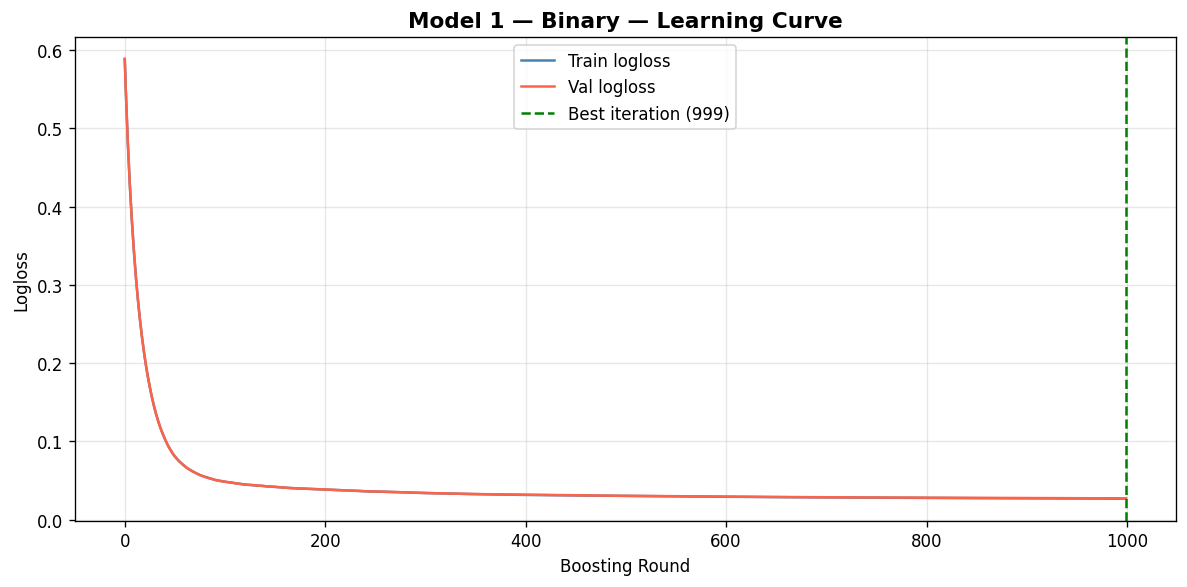

In [24]:
evals = xgb_bin.evals_result()
train_loss = evals['validation_0']['logloss']
val_loss   = evals['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(train_loss, label='Train logloss', color='steelblue')
ax.plot(val_loss,   label='Val logloss',   color='tomato')
ax.axvline(xgb_bin.best_iteration, color='green', linestyle='--',
           label=f'Best iteration ({xgb_bin.best_iteration})')
ax.set_title('Model 1 — Binary — Learning Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Logloss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix

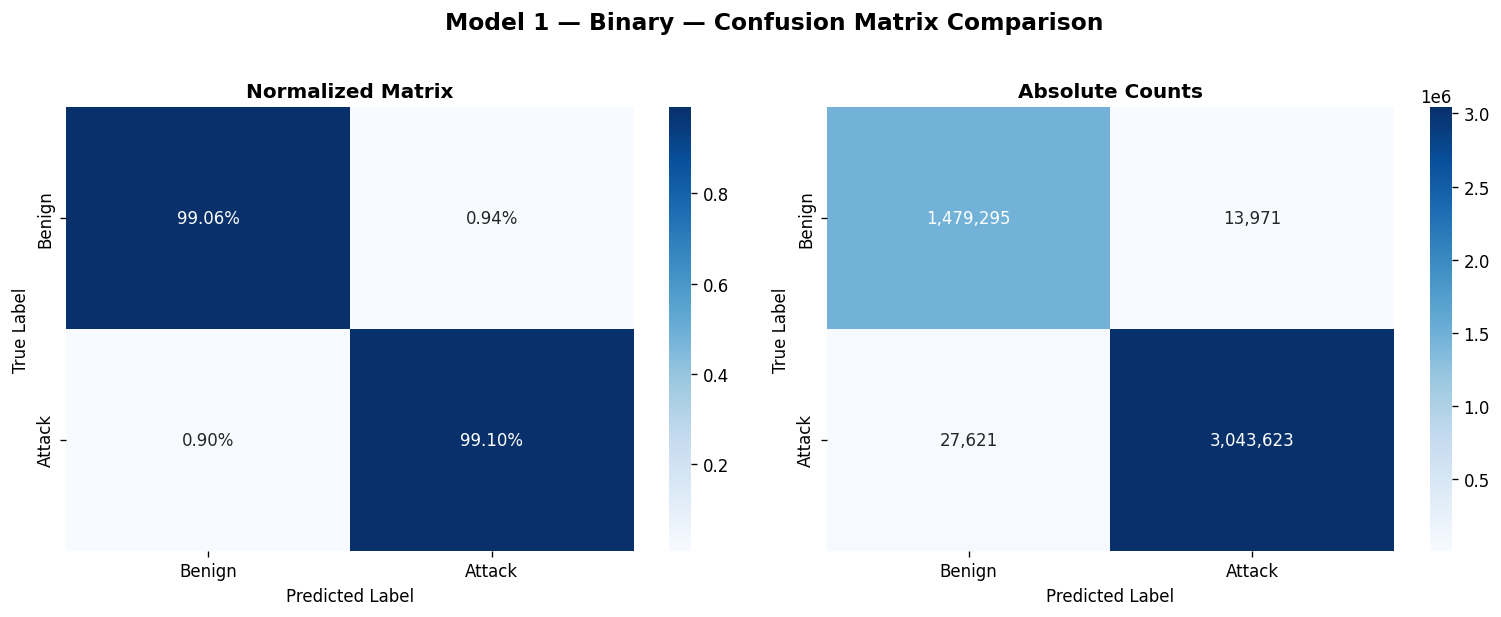

In [25]:
cm_norm = confusion_matrix(y_test_bin, preds_bin, normalize='true')
cm_raw = confusion_matrix(y_test_bin, preds_bin)


fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
labels = ['Benign', 'Attack']

# Left Subplot: Normalized percentages
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Normalized Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Right Subplot: Raw sample counts
sns.heatmap(cm_raw, annot=True, fmt=',d', cmap='Blues', # ',d' adds thousands commas
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Absolute Counts', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

fig.suptitle('Model 1 — Binary — Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_confusion_matrix_side_by_side.png', dpi=120, bbox_inches='tight')
plt.show()


## ROC Curve

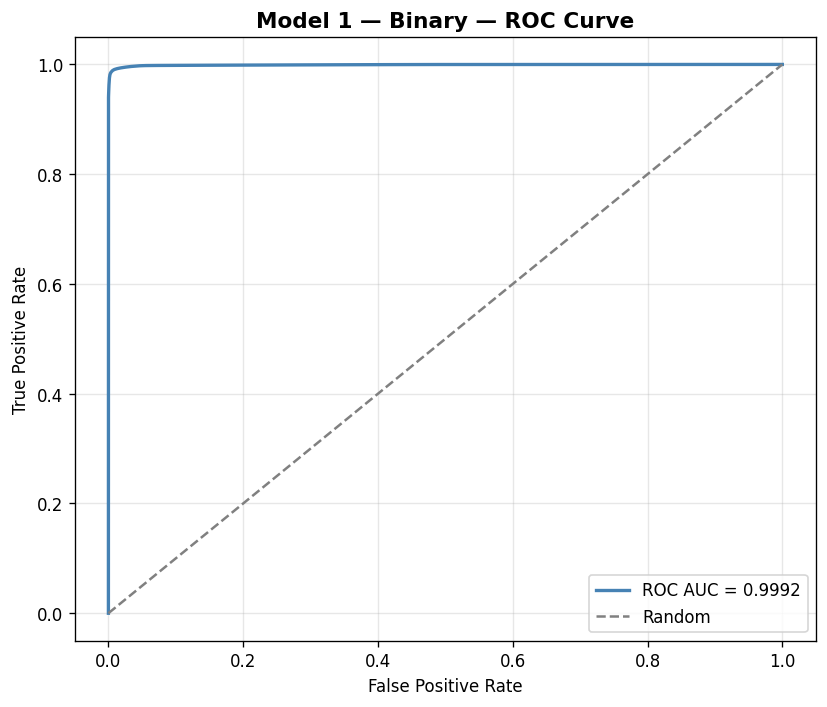

In [26]:

proba_bin  = xgb_bin.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_bin, proba_bin)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
ax.set_title('Model 1 — Binary — ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_roc.png', dpi=120, bbox_inches='tight')
plt.show()

## Precision_Recall Curve

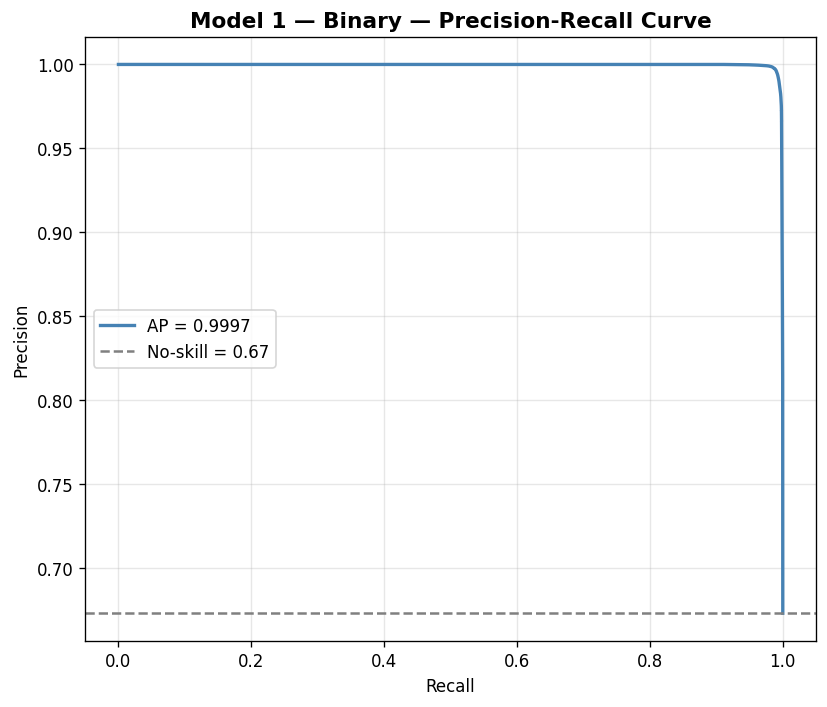

In [27]:
precision, recall, _ = precision_recall_curve(y_test_bin, proba_bin)
ap = average_precision_score(y_test_bin, proba_bin)
no_skill = y_test_bin.mean()

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.plot(recall, precision, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
ax.axhline(no_skill, color='gray', linestyle='--', label=f'No-skill = {no_skill:.2f}')
ax.set_title('Model 1 — Binary — Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

#  Feature Importance

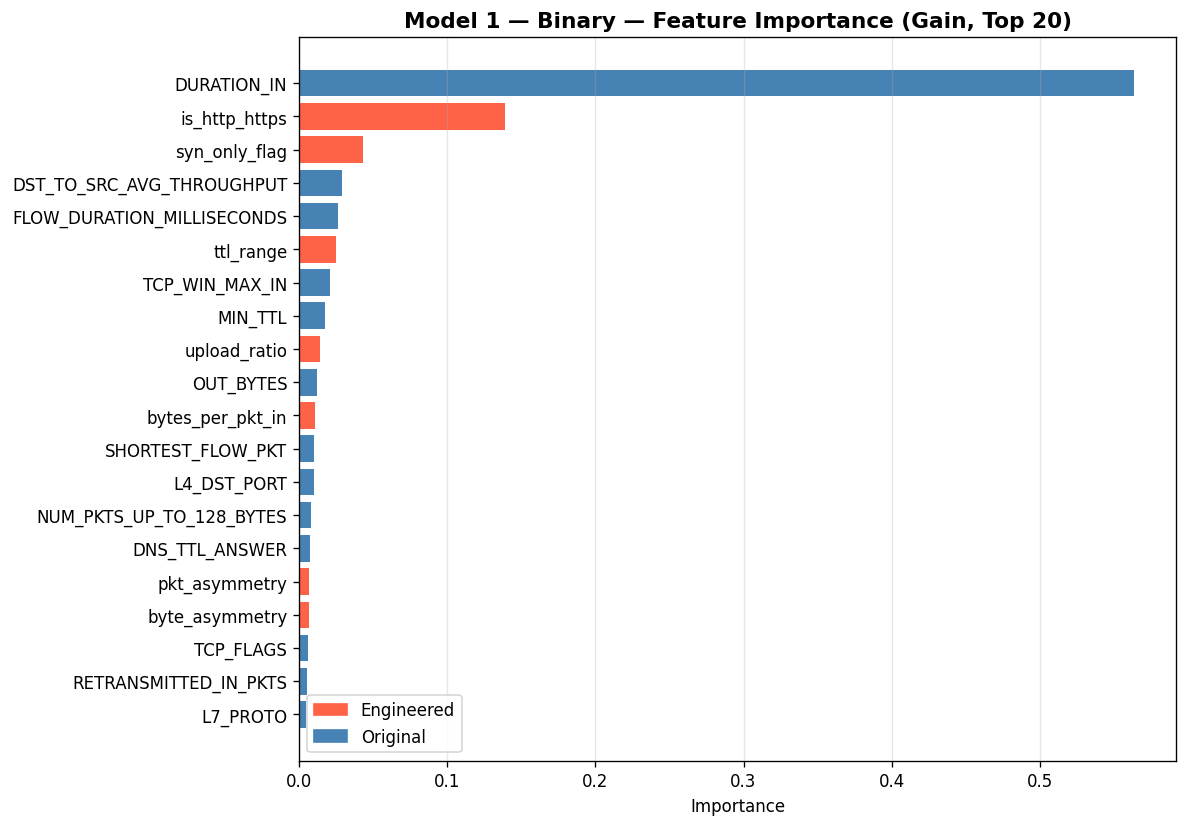

In [28]:
mi_cols = joblib.load(f'{artefacts_dir}/mi_selected_cols.pkl')
engineered = {
    'bytes_per_pkt_in', 'bytes_per_pkt_out', 'upload_ratio',
    'byte_asymmetry', 'pkt_asymmetry', 'is_http_https',
    'is_ssh_telnet', 'is_dns', 'ttl_range', 'syn_only_flag',
    'pkt_size_range', 'retransmit_ratio', 'retransmit_pkt_ratio'
}

importance   = xgb_bin.feature_importances_
feat_df      = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df      = feat_df.sort_values('importance', ascending=False).head(20)
colors       = ['tomato' if f in engineered else 'steelblue'
                for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 1 — Binary — Feature Importance (Gain, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## Model 2 
Full Multiclass (21 classes including Benign)


In [29]:
n_classes_full = len(np.unique(y_train_multi))
sw_multi = make_sample_weights(y_train_multi,log_smoothed_multi_dict)
sw_multi


array([1.       , 1.       , 1.       , ..., 1.2673619, 1.       ,
       1.       ], dtype=float32)

In [30]:
best_params_multi = {
    'max_depth'        : 8,      
    'learning_rate'    : 0.03,  
    'n_estimators'     : 1500,  
    'subsample'        : 0.8,    
    'colsample_bytree' : 0.6,                             
    'min_child_weight' : 25,                             
    'gamma'            : 1.0,                            
    'reg_alpha'        : 1.0,    
    'reg_lambda'       : 3.0,   
}



xgb_multi = XGBClassifier(
    **best_params_multi,
    objective='multi:softmax',
    num_class=n_classes_full,
    eval_metric='mlogloss',       
    early_stopping_rounds=50,    
    tree_method='hist',
    device='cuda',
    use_label_encoder=False,
    random_state=random_seed,
    verbosity=1                  
)

xgb_multi.fit(
    X_train, y_train_multi,
    sample_weight=sw_multi,     
    eval_set=[(X_train, y_train_multi), (X_val, y_val_multi)],
    verbose=100                  
)

joblib.dump(xgb_multi, f'{models_dir}/xgb_multiclass.pkl')


[0]	validation_0-mlogloss:1.51876	validation_1-mlogloss:1.51877
[100]	validation_0-mlogloss:0.14836	validation_1-mlogloss:0.14843
[200]	validation_0-mlogloss:0.08451	validation_1-mlogloss:0.08474
[300]	validation_0-mlogloss:0.07532	validation_1-mlogloss:0.07568
[400]	validation_0-mlogloss:0.07126	validation_1-mlogloss:0.07175
[500]	validation_0-mlogloss:0.06789	validation_1-mlogloss:0.06854
[600]	validation_0-mlogloss:0.06489	validation_1-mlogloss:0.06570
[700]	validation_0-mlogloss:0.06266	validation_1-mlogloss:0.06363
[800]	validation_0-mlogloss:0.06070	validation_1-mlogloss:0.06183
[900]	validation_0-mlogloss:0.05915	validation_1-mlogloss:0.06044
[1000]	validation_0-mlogloss:0.05794	validation_1-mlogloss:0.05938
[1100]	validation_0-mlogloss:0.05688	validation_1-mlogloss:0.05847
[1200]	validation_0-mlogloss:0.05589	validation_1-mlogloss:0.05761
[1300]	validation_0-mlogloss:0.05499	validation_1-mlogloss:0.05684
[1400]	validation_0-mlogloss:0.05421	validation_1-mlogloss:0.05619
[1499]	

['/kaggle/working/models_xgboost/xgb_multiclass.pkl']

## Test model_2 performance on the test set

In [31]:
preds_multi = evaluate(xgb_multi, X_test, y_test_multi,
                        label='Model_2_Full_Multiclass_on_Test_Set',class_names=le.classes_)


Model_2_Full_Multiclass_on_Test_Set
Accuracy         : 0.9823
Macro-F1         : 0.8208
Weighted-F1      : 0.9820
                precision    recall  f1-score   support

      Analysis       0.03      0.08      0.05        75
      Backdoor       0.94      0.95      0.94      1165
        Benign       0.98      0.99      0.99   1493266
           Bot       1.00      1.00      1.00      3920
   Brute Force       1.00      0.98      0.99      8165
          DDoS       1.00      0.99      1.00   1310954
           DoS       0.98      0.99      0.99   1088123
      Exploits       0.78      0.92      0.84      1984
       Fuzzers       0.77      0.93      0.84      1384
       Generic       0.76      0.84      0.80       645
 Infilteration       0.41      0.27      0.32      7646
Reconnaissance       0.93      0.84      0.89    166365
     Shellcode       0.82      0.89      0.86        76
         Theft       0.66      0.94      0.78       141
         Worms       0.73      0.76      0.7

## Learning Curve

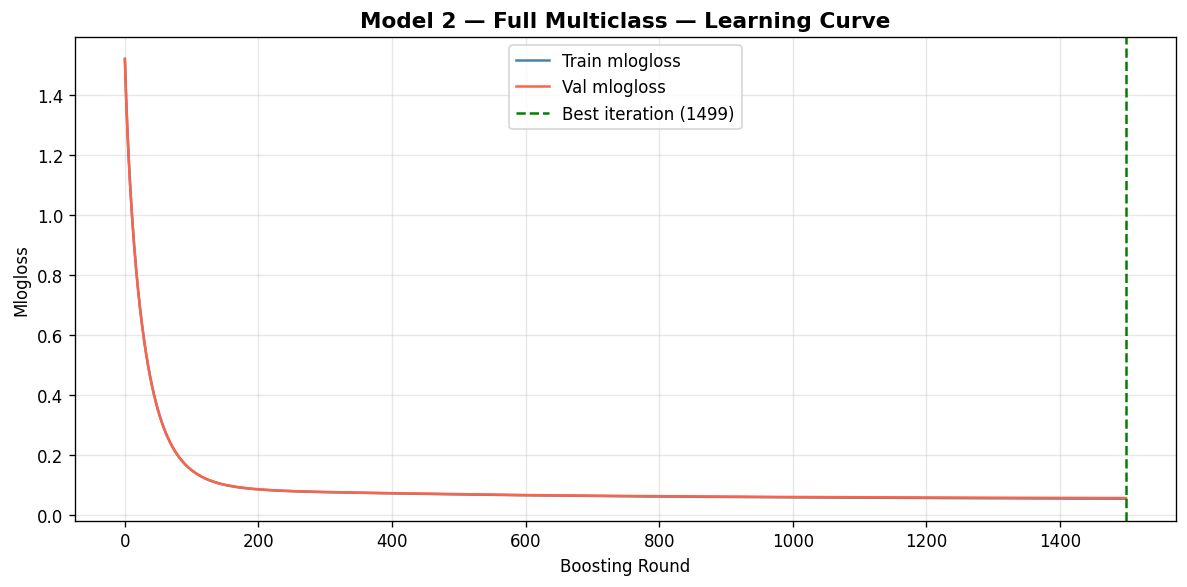

In [32]:
evals = xgb_multi.evals_result()
train_loss = evals['validation_0']['mlogloss']
val_loss   = evals['validation_1']['mlogloss']

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(train_loss, label='Train mlogloss', color='steelblue')
ax.plot(val_loss,   label='Val mlogloss',   color='tomato')
ax.axvline(xgb_multi.best_iteration, color='green', linestyle='--',
           label=f'Best iteration ({xgb_multi.best_iteration})')
ax.set_title('Model 2 — Full Multiclass — Learning Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Mlogloss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix (normalized)

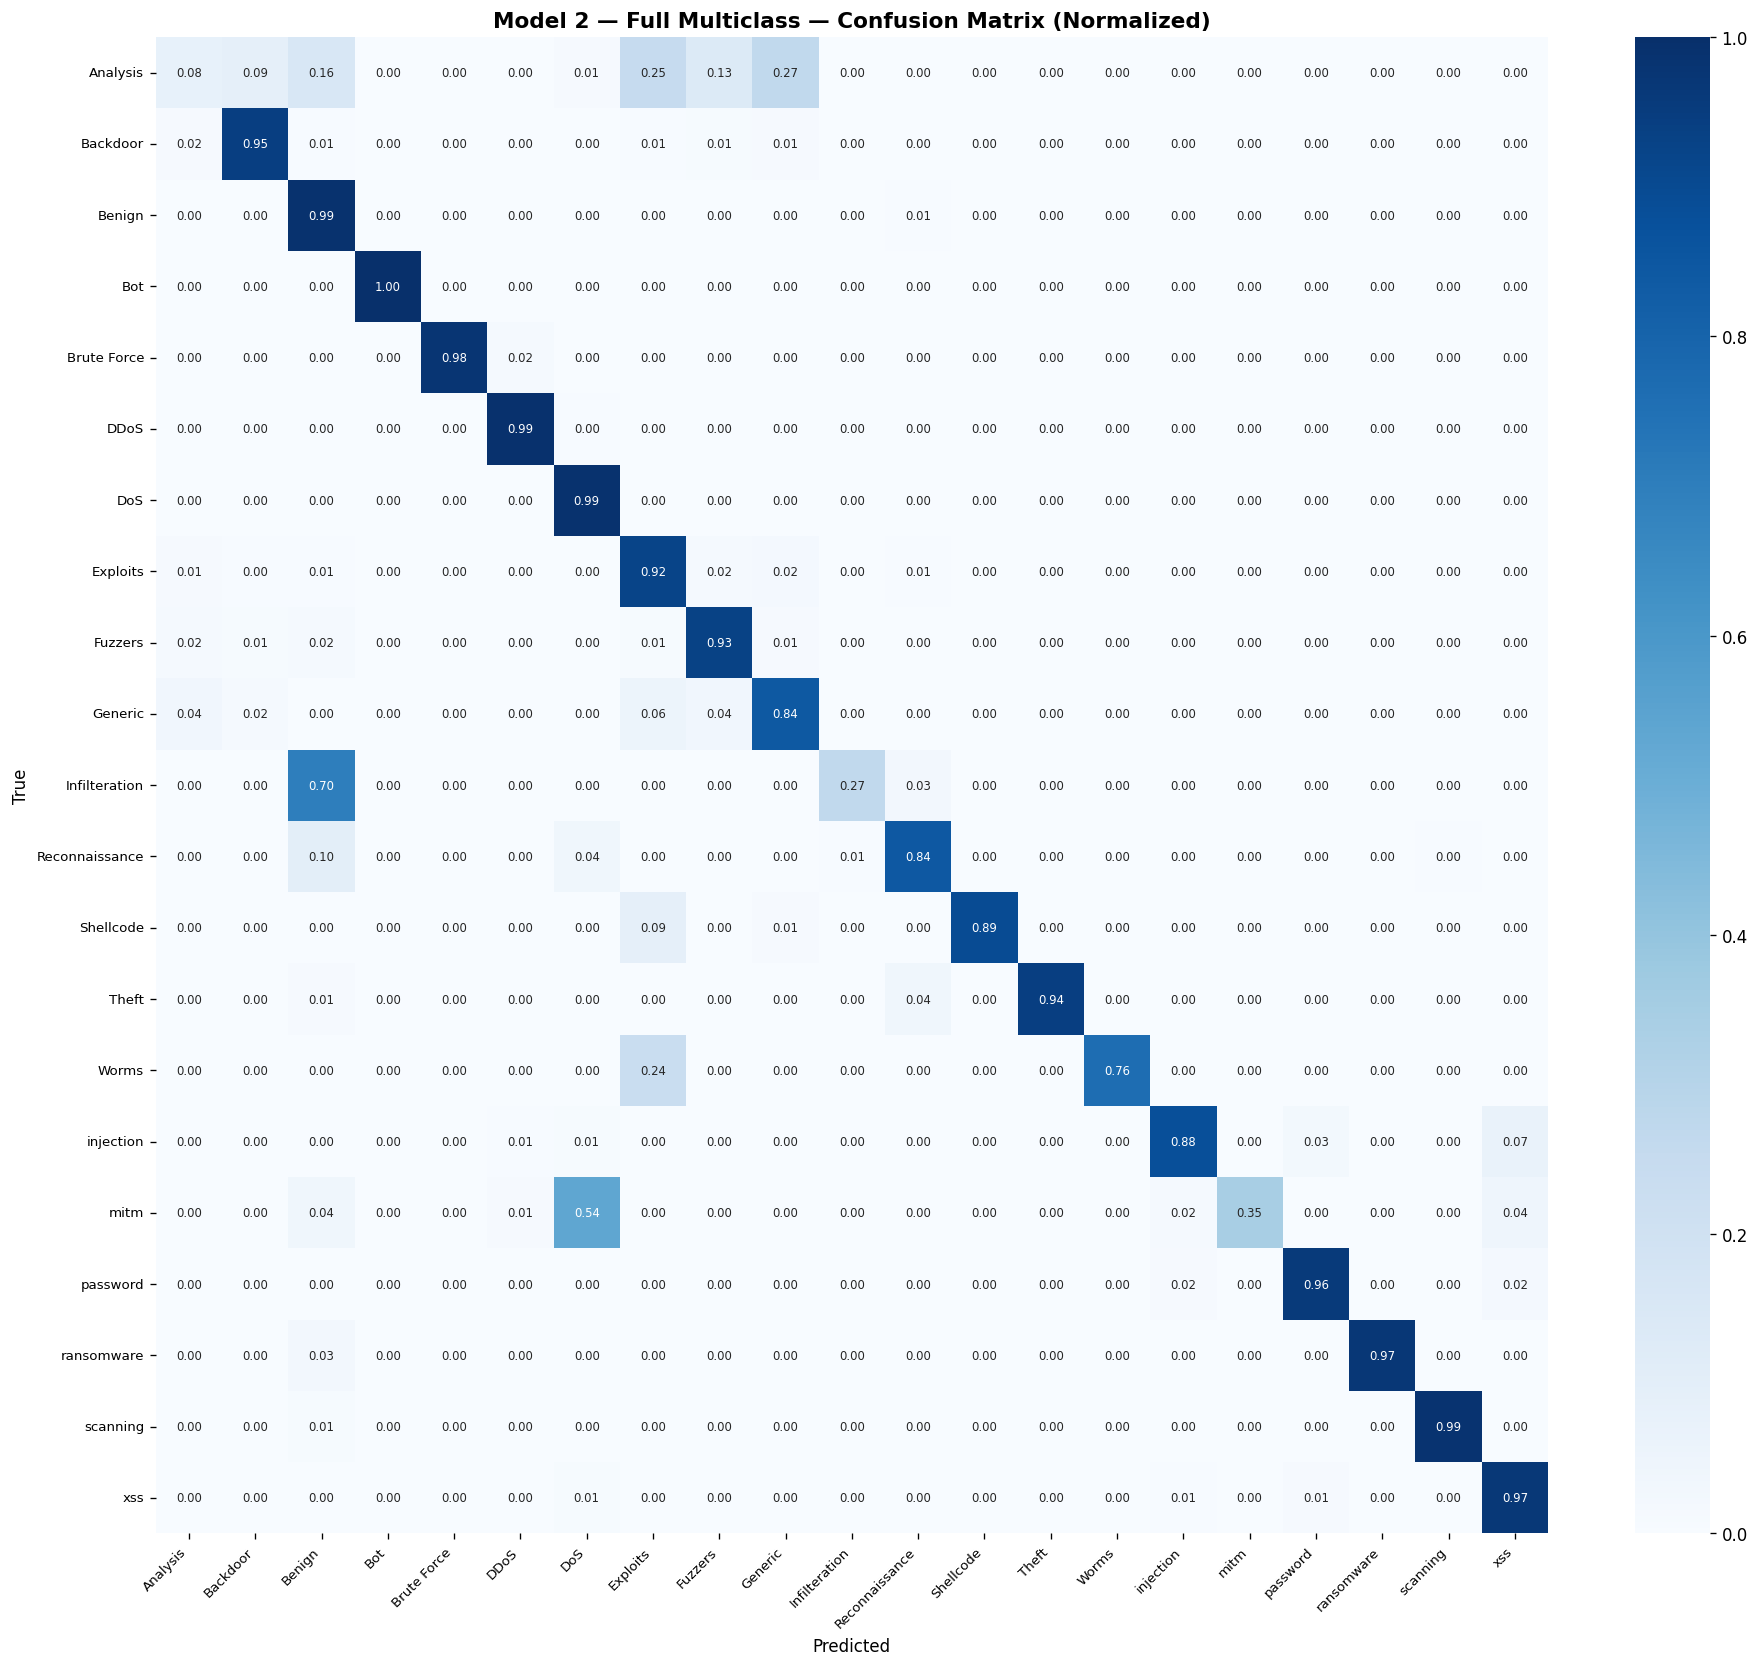

In [33]:
cm = confusion_matrix(y_test_multi, preds_multi, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Model 2 — Full Multiclass — Confusion Matrix (Normalized)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class F1 bar chart

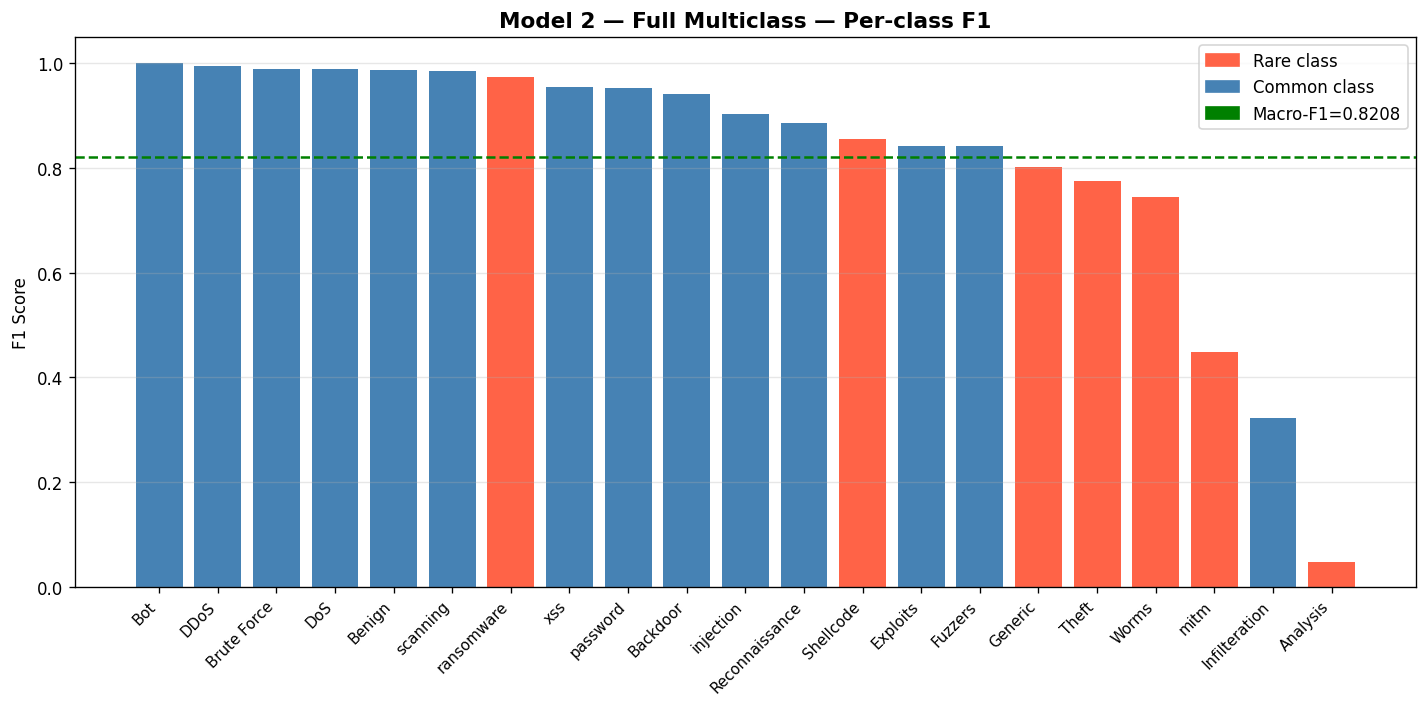

In [34]:
from sklearn.metrics import f1_score
report   = classification_report(y_test_multi, preds_multi,
                                  target_names=le.classes_,
                                  output_dict=True, zero_division=0)
f1_vals  = {cls: report[cls]['f1-score'] for cls in le.classes_}
f1_df    = pd.DataFrame(list(f1_vals.items()), columns=['class', 'f1'])
f1_df    = f1_df.sort_values('f1', ascending=False)
macro_f1 = report['macro avg']['f1-score']

rare = {'Worms','Shellcode','Analysis','Theft','ransomware','mitm','Generic'}
colors = ['tomato' if c in rare else 'steelblue' for c in f1_df['class']]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(f1_df['class'], f1_df['f1'], color=colors)
ax.axhline(macro_f1, color='green', linestyle='--',
           label=f'Macro-F1 = {macro_f1:.4f}')
ax.set_title('Model 2 — Full Multiclass — Per-class F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
patches = [mpatches.Patch(color='tomato',    label='Rare class'),
           mpatches.Patch(color='steelblue', label='Common class')]
ax.legend(handles=patches + [mpatches.Patch(color='green', label=f'Macro-F1={macro_f1:.4f}')])
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class Precision_Recall heatmap

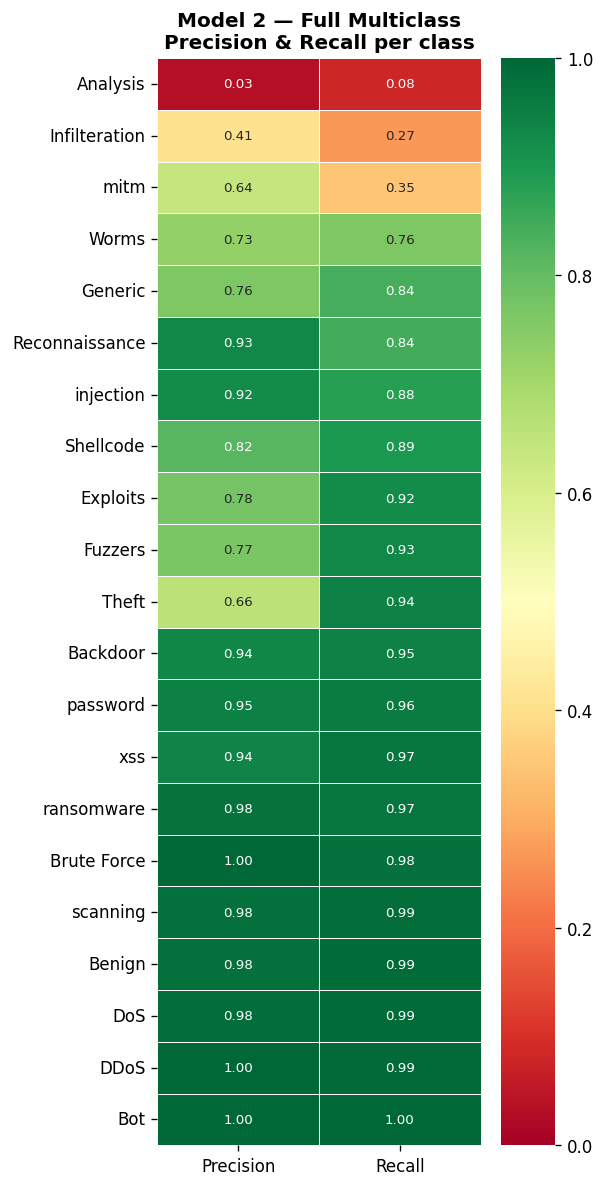

In [35]:
prec_vals = {cls: report[cls]['precision'] for cls in le.classes_}
rec_vals  = {cls: report[cls]['recall']    for cls in le.classes_}
pr_df = pd.DataFrame({'Precision': prec_vals, 'Recall': rec_vals})
pr_df = pr_df.sort_values('Recall', ascending=True)

fig, ax = plt.subplots(figsize=(5, 10), dpi=120)
sns.heatmap(pr_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Model 2 — Full Multiclass\nPrecision & Recall per class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_precision_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance

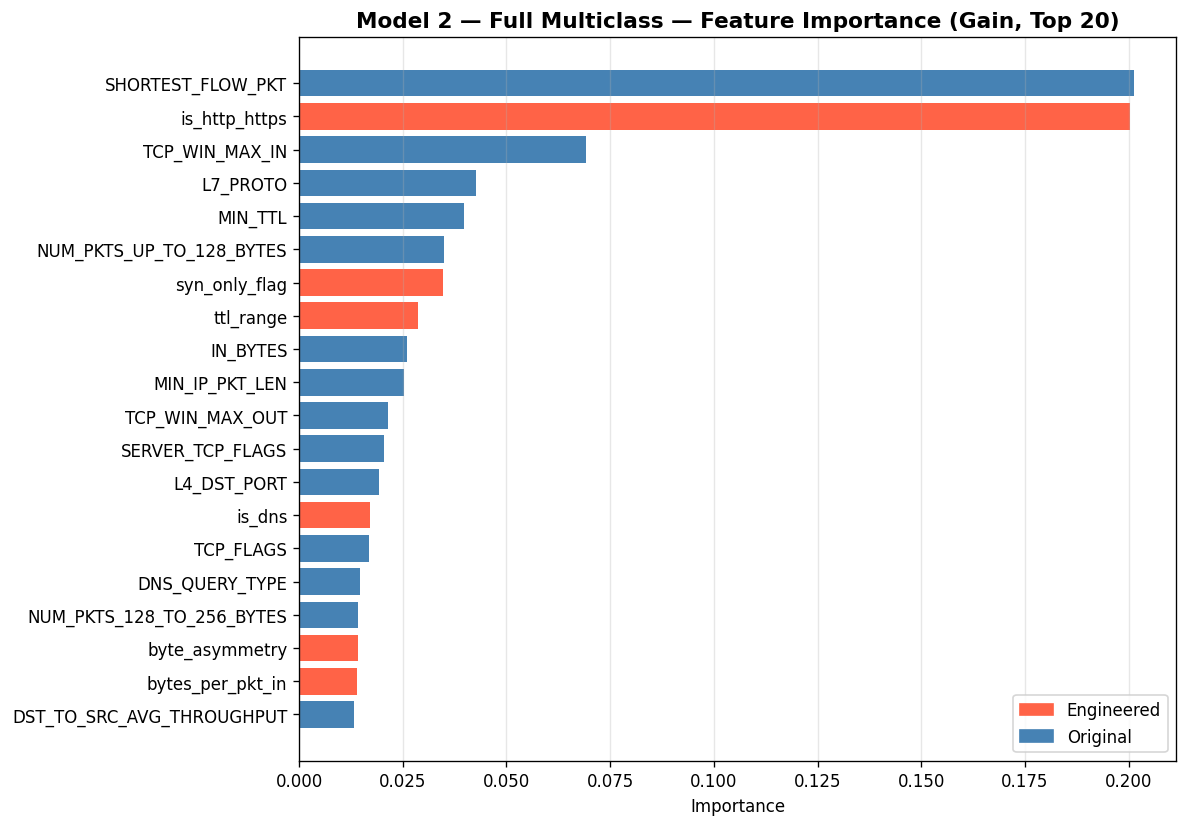

In [36]:
importance   = xgb_multi.feature_importances_
feat_df      = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df      = feat_df.sort_values('importance', ascending=False).head(20)
colors       = ['tomato' if f in engineered else 'steelblue'
                for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 2 — Full Multiclass — Feature Importance (Gain, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## Model 3 
Attack-Only Multiclass (20 classes, no Benign)


In [37]:
n_classes_att = len(np.unique(y_train_att_multi))
sw_att = make_sample_weights(y_train_att_multi, log_smoothed_att_dict)
sw_att


array([1.       , 1.       , 1.       , ..., 1.7634389, 1.       ,
       1.       ], dtype=float32)

In [38]:
best_params_att = {
    'max_depth'        : 8,                             
    'learning_rate'    : 0.03,   
    'n_estimators'     : 1500,  
    'subsample'        : 0.75,  
    'colsample_bytree' : 0.6,                           
    'min_child_weight' : 15,                     
    'gamma'            : 0.8,                            
    'reg_alpha'        : 0.5,   
    'reg_lambda'       : 3.0,    
}

le_att = LabelEncoder()
y_train_att_encoded = le_att.fit_transform(y_train_att_multi)


y_val_att_encoded = le_att.transform(y_val_att_multi)


xgb_att = XGBClassifier(
    **best_params_att,
    objective='multi:softmax',
    num_class=n_classes_att,  # This is 20
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    tree_method='hist',
    device='cuda',
    use_label_encoder=False,
    random_state=random_seed,
    verbosity=1
)

xgb_att.fit(
    X_train_att, y_train_att_encoded,  
    sample_weight=sw_att,
    eval_set=[(X_train_att, y_train_att_encoded), (X_val_att, y_val_att_encoded)],
    verbose=100
)

joblib.dump(xgb_att, f'{models_dir}/xgb_att_multiclass.pkl')
joblib.dump(le_att, f'{models_dir}/le_att_multiclass.pkl')



[0]	validation_0-mlogloss:1.35369	validation_1-mlogloss:1.35375
[100]	validation_0-mlogloss:0.11892	validation_1-mlogloss:0.11907
[200]	validation_0-mlogloss:0.06622	validation_1-mlogloss:0.06649
[300]	validation_0-mlogloss:0.05891	validation_1-mlogloss:0.05931
[400]	validation_0-mlogloss:0.05592	validation_1-mlogloss:0.05644
[500]	validation_0-mlogloss:0.05323	validation_1-mlogloss:0.05390
[600]	validation_0-mlogloss:0.05022	validation_1-mlogloss:0.05107
[700]	validation_0-mlogloss:0.04784	validation_1-mlogloss:0.04887
[800]	validation_0-mlogloss:0.04580	validation_1-mlogloss:0.04700
[900]	validation_0-mlogloss:0.04412	validation_1-mlogloss:0.04549
[1000]	validation_0-mlogloss:0.04275	validation_1-mlogloss:0.04426
[1100]	validation_0-mlogloss:0.04150	validation_1-mlogloss:0.04316
[1200]	validation_0-mlogloss:0.04041	validation_1-mlogloss:0.04221
[1300]	validation_0-mlogloss:0.03940	validation_1-mlogloss:0.04134
[1400]	validation_0-mlogloss:0.03855	validation_1-mlogloss:0.04062
[1499]	

['/kaggle/working/models_xgboost/le_att_multiclass.pkl']

## Test model_3 performance on the test set

In [39]:
y_test_att_encoded = le_att.transform(y_test_att_multi)
attack_classes = [str(c) for c in le_att.classes_]
preds_att = evaluate(
    xgb_att, 
    X_test_att, 
    y_test_att_encoded,   
    label='Model_3_Attack_Only_Multiclass_on_Test_Set',
    class_names=attack_classes
)



Model_3_Attack_Only_Multiclass_on_Test_Set
Accuracy         : 0.9872
Macro-F1         : 0.8576
Weighted-F1      : 0.9872
              precision    recall  f1-score   support

           0       0.07      0.15      0.10        75
           1       0.95      0.95      0.95      1165
           3       1.00      1.00      1.00      3920
           4       1.00      0.98      0.99      8165
           5       1.00      0.99      1.00   1310954
           6       0.99      0.99      0.99   1088123
           7       0.82      0.93      0.87      1984
           8       0.91      0.95      0.93      1384
           9       0.77      0.85      0.81       645
          10       0.81      0.97      0.88      7646
          11       0.99      0.94      0.96    166365
          12       0.86      0.87      0.86        76
          13       0.66      0.94      0.78       141
          14       0.80      0.76      0.78        21
          15       0.93      0.89      0.91     44592
          16 

## Learning Curve

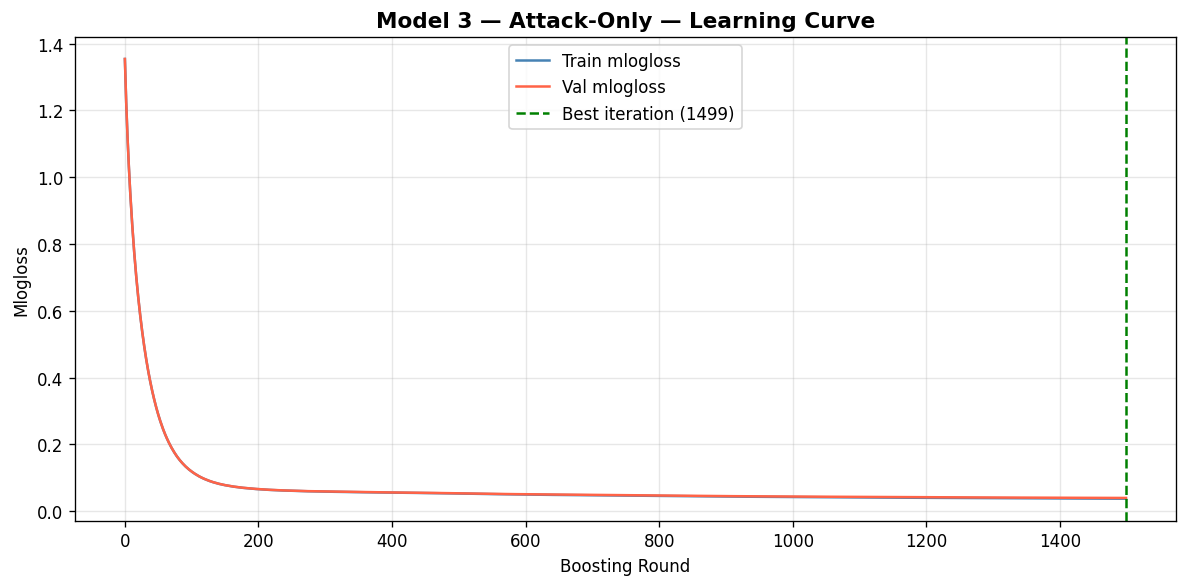

In [40]:
evals = xgb_att.evals_result()
train_loss = evals['validation_0']['mlogloss']
val_loss   = evals['validation_1']['mlogloss']

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(train_loss, label='Train mlogloss', color='steelblue')
ax.plot(val_loss,   label='Val mlogloss',   color='tomato')
ax.axvline(xgb_att.best_iteration, color='green', linestyle='--',
           label=f'Best iteration ({xgb_att.best_iteration})')
ax.set_title('Model 3 — Attack-Only — Learning Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Mlogloss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix

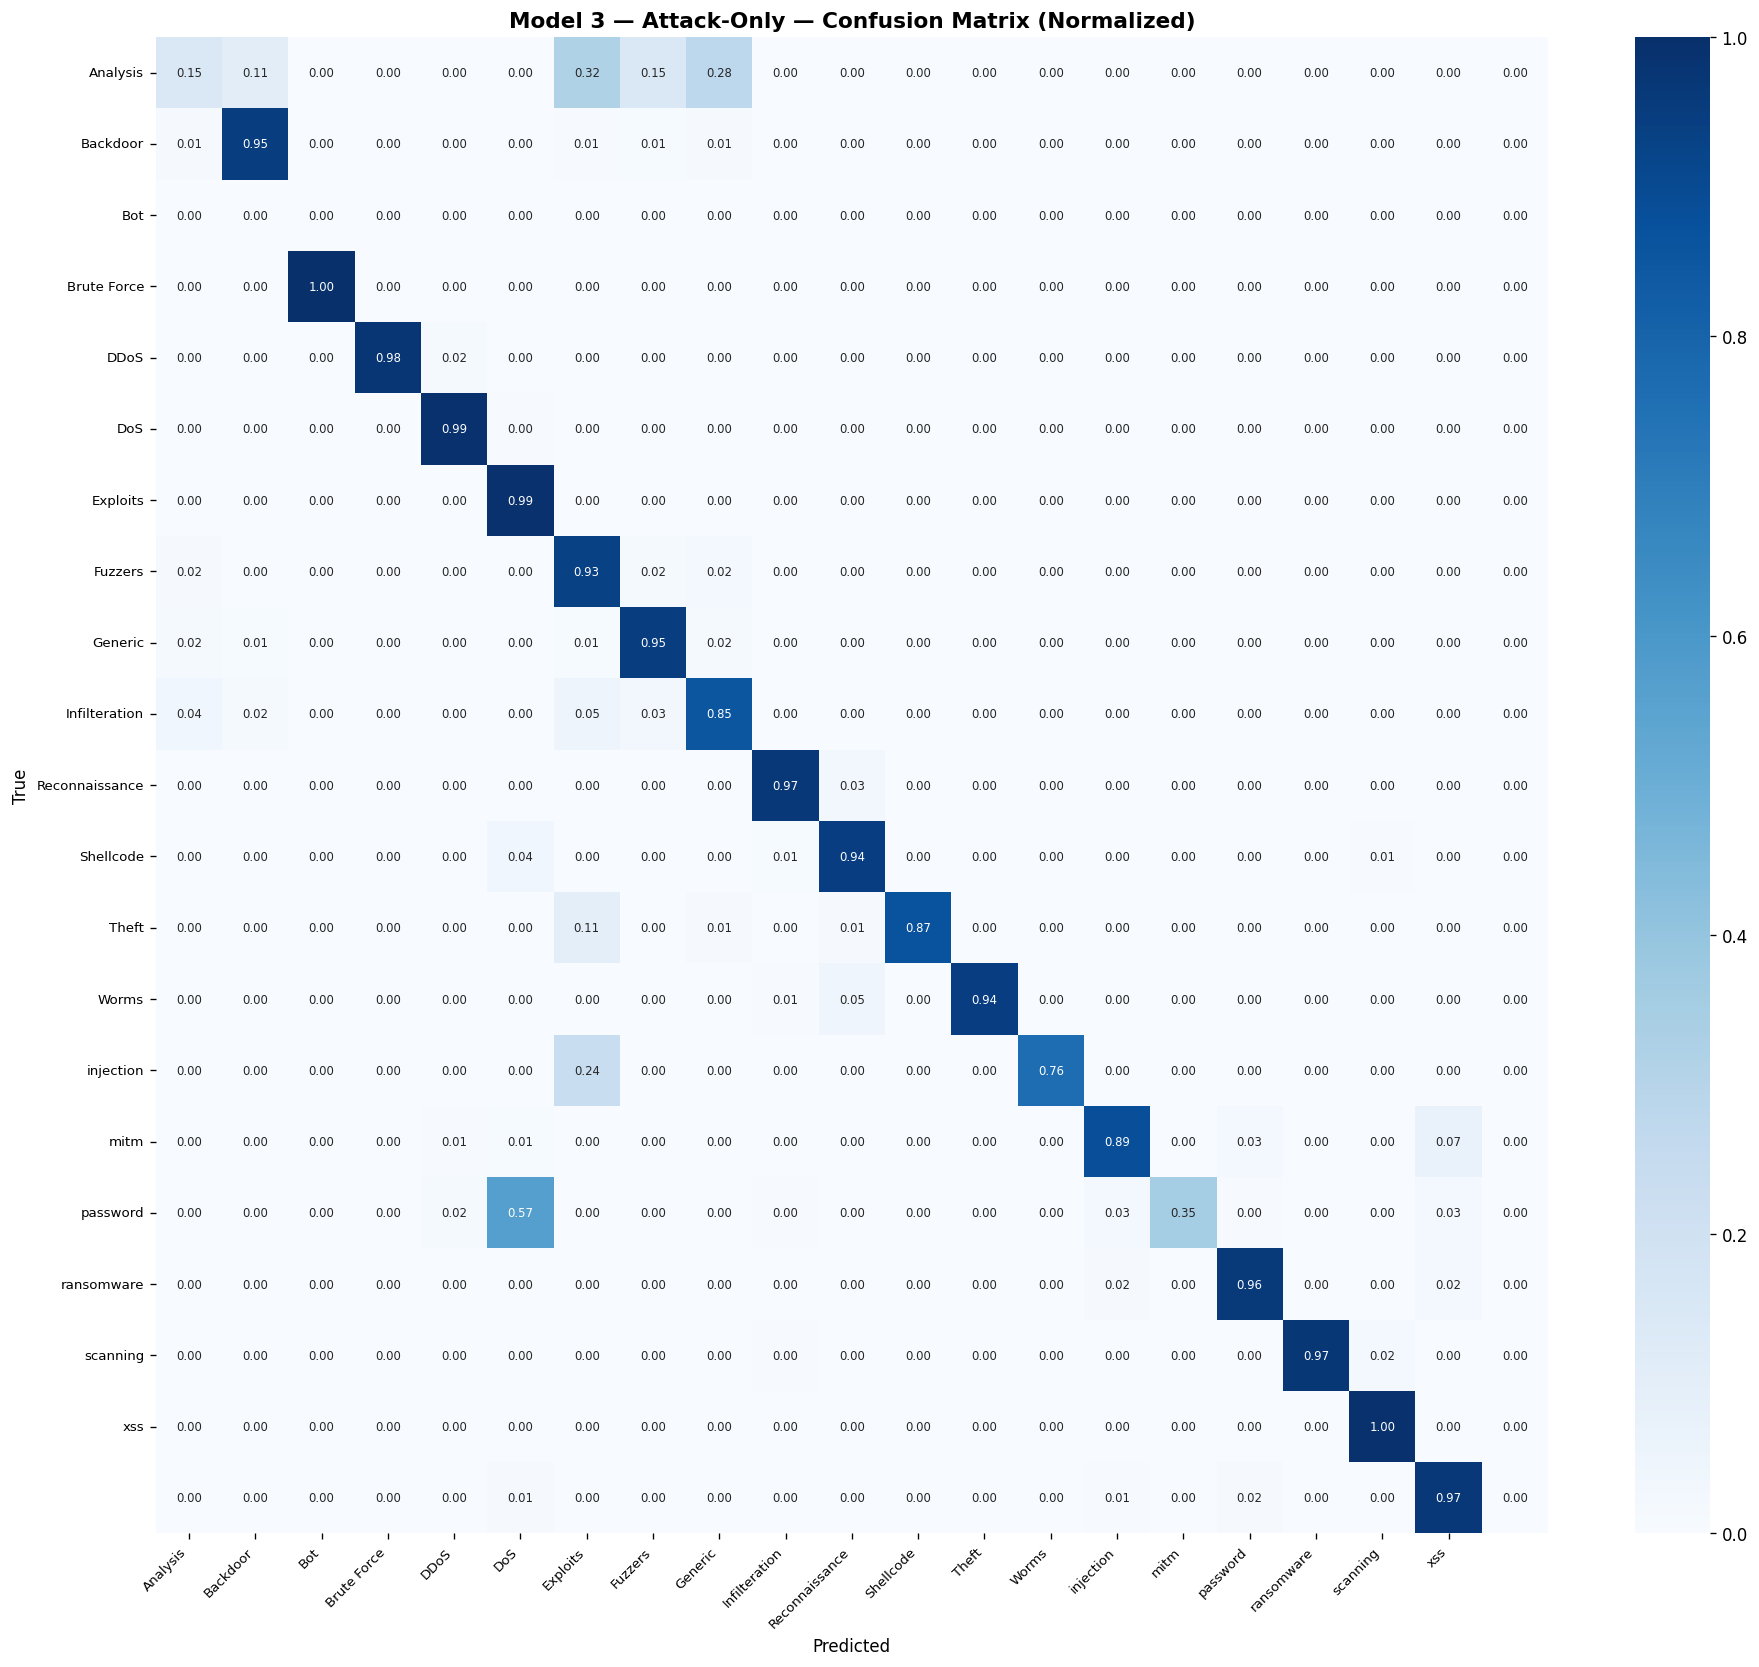

In [41]:
attack_classes = [c for c in le.classes_ if c != 'Benign']
cm = confusion_matrix(y_test_att_multi, preds_att, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=attack_classes,
            yticklabels=attack_classes, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Model 3 — Attack-Only — Confusion Matrix (Normalized)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class F1 bar chart

In [42]:
report_att = classification_report(
    y_test_att_encoded,                
    preds_att,
    target_names=attack_classes,
    output_dict=True, 
    zero_division=0
)

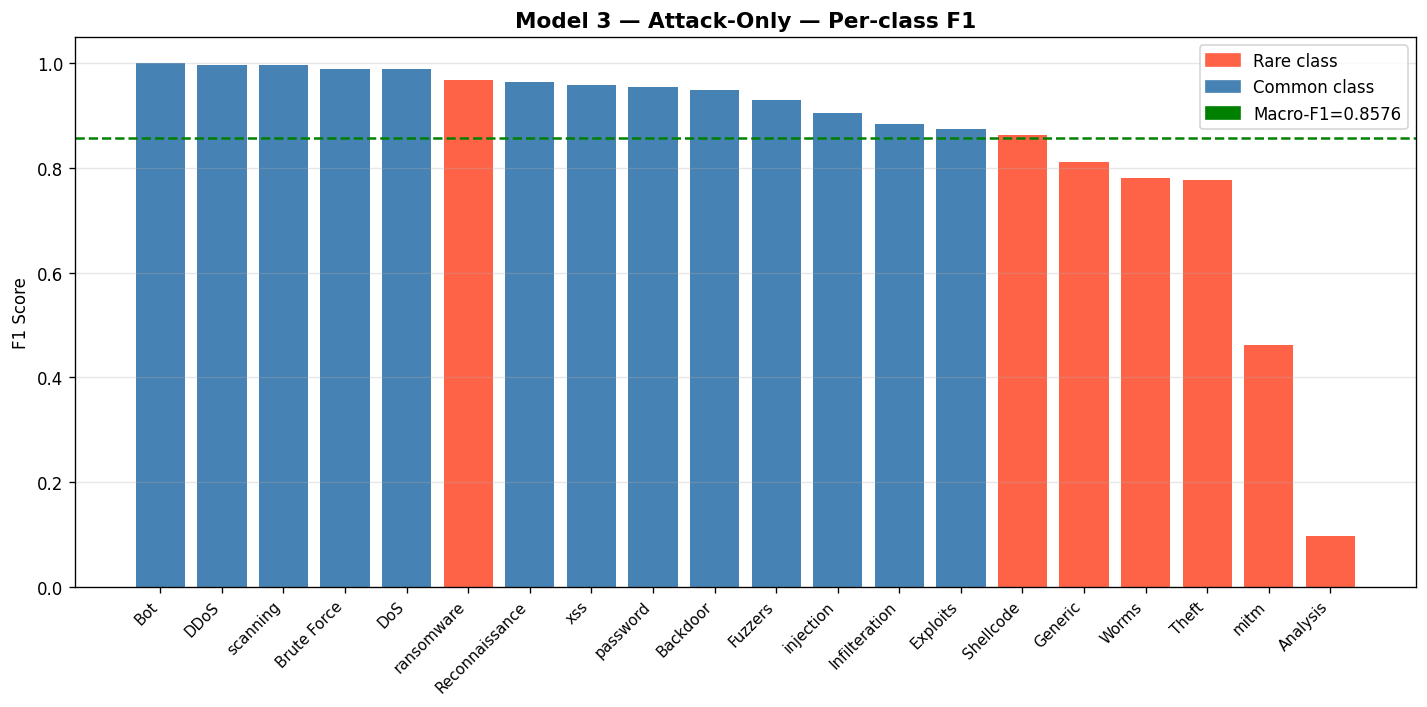

In [43]:
f1_vals_att  = {cls: report_att[cls]['f1-score'] for cls in attack_classes}
f1_df_att    = pd.DataFrame(list(f1_vals_att.items()), columns=['class', 'f1'])
f1_df_att    = f1_df_att.sort_values('f1', ascending=False)
macro_f1_att = report_att['macro avg']['f1-score']

colors = ['tomato' if c in rare else 'steelblue' for c in f1_df_att['class']]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(f1_df_att['class'], f1_df_att['f1'], color=colors)
ax.axhline(macro_f1_att, color='green', linestyle='--',
           label=f'Macro-F1 = {macro_f1_att:.4f}')
ax.set_title('Model 3 — Attack-Only — Per-class F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
patches = [mpatches.Patch(color='tomato',    label='Rare class'),
           mpatches.Patch(color='steelblue', label='Common class'),
           mpatches.Patch(color='green',     label=f'Macro-F1={macro_f1_att:.4f}')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class Precision_Recall heatmap

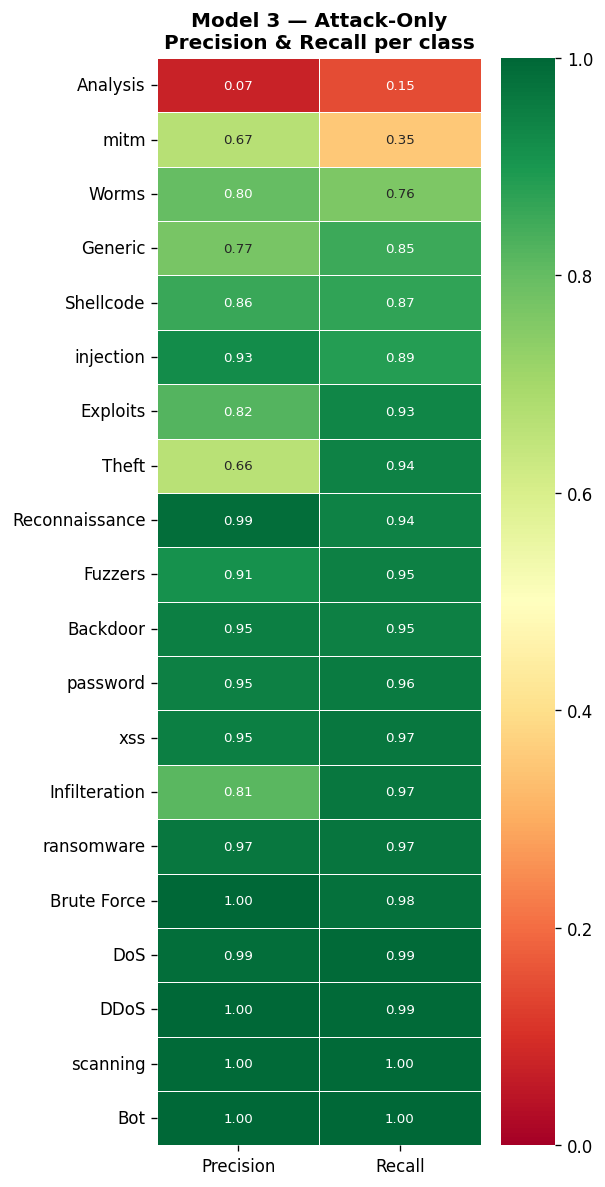

In [44]:
prec_vals_att = {cls: report_att[cls]['precision'] for cls in attack_classes}
rec_vals_att  = {cls: report_att[cls]['recall']    for cls in attack_classes}
pr_df_att = pd.DataFrame({'Precision': prec_vals_att, 'Recall': rec_vals_att})
pr_df_att = pr_df_att.sort_values('Recall', ascending=True)

fig, ax = plt.subplots(figsize=(5, 10), dpi=120)
sns.heatmap(pr_df_att, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Model 3 — Attack-Only\nPrecision & Recall per class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_precision_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance

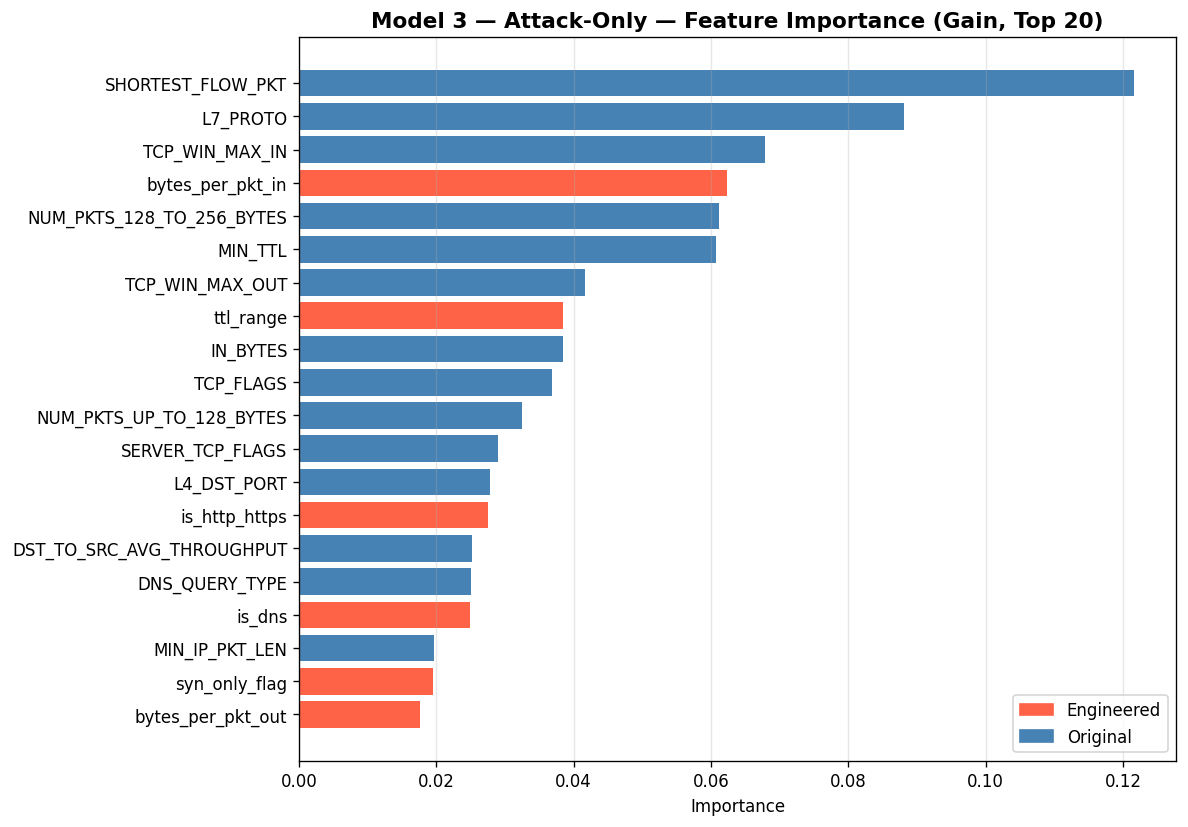

In [45]:
importance   = xgb_att.feature_importances_
feat_df      = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df      = feat_df.sort_values('importance', ascending=False).head(20)
colors       = ['tomato' if f in engineered else 'steelblue'
                for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 3 — Attack-Only — Feature Importance (Gain, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## Papers comparison done on the same dataset NF-UQ-NID

In [46]:
papers = [
    "Sarhan\n2022",
    "Wijethilaka\n2025",
    "Mouatassim\n2024",
    "Bouzaachane\n2025",
    "Gu\n2024",
    "Krupski\n2024",
    "Komisarek\n2021",
    "Gouda\n2024",
    "Adeniyi\n2024",
    "My Models"
]


In [51]:
# Binary
binary_scores = [
    0.9800,      # Sarhan ET Binary
    0.9480,      # Wijethilaka RF
    0.999939,    # Mouatassim XGB Binary
    1.0000,      # Bouzaachane RF Binary
    np.nan,      # Gu
    0.9530,      # Krupski DT 8feat
    0.9800,      # Komisarek RF
    0.9910,      # Gouda RF
    0.9890,      # Adeniyi AE-MLP
    0.9909       # My Binary
]

# Full multiclass
multi_scores = [
    0.9700,      # Sarhan ET Multi
    0.8750,      # Wijethilaka LSTM
    0.9928,      # Mouatassim XGB Multi
    0.9900,      # Bouzaachane DBN Multi
    0.8900,      # Gu GNN
    0.9720,      # Krupski DT 30feat
    np.nan,
    np.nan,
    np.nan,
    0.9820       # My Full Multi
]

# Attack-only multiclass
attack_only_scores = [
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    0.9872       # My Attack-only
]


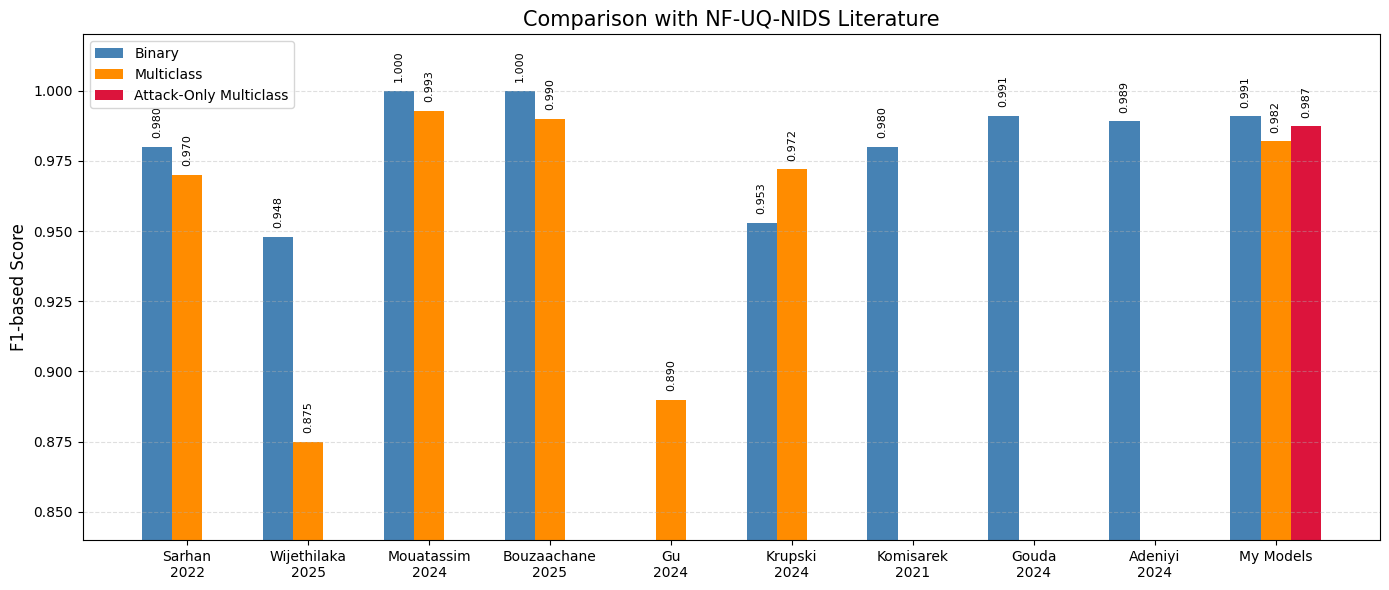

In [52]:
x = np.arange(len(papers))
width = 0.25
plt.figure(figsize=(14, 6))
bars1 = plt.bar(x - width,binary_scores,width,label='Binary',color='steelblue')
bars2 = plt.bar(x,multi_scores,width,label='Multiclass', color='darkorange')
bars3 = plt.bar(x + width,attack_only_scores,width,label='Attack-Only Multiclass',color='crimson')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            plt.text(bar.get_x() + bar.get_width()/2,height + 0.003,f"{height:.3f}",ha='center',va='bottom',fontsize=8,rotation=90 )


plt.xticks(x, papers, fontsize=10)

plt.ylabel("F1-based Score", fontsize=12)

plt.title(
    "Comparison with NF-UQ-NIDS Literature",
    fontsize=15
)

plt.ylim(0.84, 1.02)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(f'{plots_dir}/papers_comparison', dpi=120, bbox_inches='tight')
plt.show()

## Saving ther Artefacts and the Models

In [53]:
import os
import shutil
from IPython.display import FileLink, display


models_dir = '/kaggle/working/models_xgboost'
models_zip = 'xgboost_models.zip'

if os.path.exists(models_dir):
    shutil.make_archive('xgboost_models', 'zip', models_dir)
    print(" XGBoost Models:")
    display(FileLink(models_zip))
else:
    print(f" Directory not found: {models_dir}")


 XGBoost Models:


/kaggle/working/xgboost_models.zip

In [54]:
plots_dir = '/kaggle/working/plots_xgboost'
plots_zip = 'xgboost_plots.zip'

if os.path.exists(plots_dir):
    shutil.make_archive('xgboost_plots', 'zip', plots_dir)
    print(" XGBoost Plots:")
    display(FileLink(plots_zip))
else:
    print(f" Directory not found: {plots_dir}")



 XGBoost Plots:


/kaggle/working/xgboost_plots.zip